In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import math

import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from skimage.morphology import disk, opening, closing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from pathlib import Path

from toolbox_34759.clustering import plot_elbow_graph
from toolbox_34759.camera_model import PinholeCameraModel, CameraMatrix
from toolbox_34759.coordinates import EuclideanPoint, HomogeneousPoint

In [3]:
DATA_PATH = Path('data')

# Q10

(32, 1, 2)

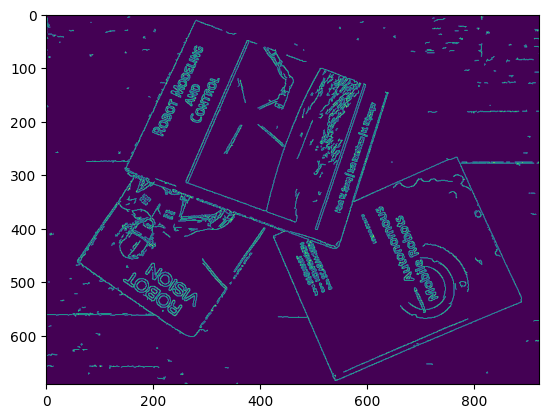

In [4]:
img = cv2.imread(DATA_PATH / 'books.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
cedges = cv2.Canny(gray, 100, 200)
lines = cv2.HoughLines(cedges, rho=1, theta=0.0017, threshold=200)

plt.imshow(cedges)
lines.shape


# Q11

In [5]:
img = cv2.imread(DATA_PATH / 'books.png')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
corners = cv2.cornerHarris(gray, blockSize=2, ksize=3, k=0.04)

(corners > 0.01).astype(int).sum()

np.int64(188)

# Q12

In [6]:
img1 = cv2.imread(DATA_PATH / 'things1.png')
img2 = cv2.imread(DATA_PATH / 'things2.png')
gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)

features1 = cv2.goodFeaturesToTrack(gray1, maxCorners=100, qualityLevel=0.3, minDistance=7)
features2, status, error = cv2.calcOpticalFlowPyrLK(gray1, gray2, features1, None)

max_x_dist = 0
for i in range(len(features1)):
    if status[i] != 1:
        continue
    
    f1_x = features1[i][0][0]
    f2_x = features2[i][0][0]

    dist = abs(f2_x - f1_x)
    if dist > max_x_dist:
        max_x_dist = dist

max_x_dist


np.float32(15.636841)

# Q18

In [7]:
left = cv2.imread(DATA_PATH / 'left.png', cv2.IMREAD_GRAYSCALE)
# DOESN'T WORK BECAUSE THE VALUES ARE CONVERTED INCORRECTLY?
# left_test = cv2.imread(DATA_PATH / 'left.png')
# left_test = cv2.cvtColor(left_test, cv2.COLOR_BGR2GRAY)
# print(np.allclose(left, left_test))
right = cv2.imread(DATA_PATH / 'right.png', cv2.IMREAD_GRAYSCALE)

sift = cv2.SIFT.create()
kp1, des1 = sift.detectAndCompute(left, None)
kp2, des2 = sift.detectAndCompute(right, None)

bf = cv2.BFMatcher()
matches = bf.match(des1, des2)

# Sort them in the order of their distance (i.e. best matches first).
matches = sorted(matches, key=lambda x: x.distance)

nb_matches = 2000
pts1 = np.zeros((nb_matches, 2), dtype=np.int32)
pts2 = np.zeros((nb_matches, 2), dtype=np.int32)

for i, m in enumerate(matches[:nb_matches]):
    pts1[i] = kp1[m.queryIdx].pt
    pts2[i] = kp2[m.trainIdx].pt

F, mask = cv2.findFundamentalMat(pts1, pts2, cv2.FM_RANSAC)

# We select only inlier points
pts1 = np.int32(pts1[mask.ravel() == 1])
pts2 = np.int32(pts2[mask.ravel() == 1])

lines1 = cv2.computeCorrespondEpilines(pts2.reshape(-1, 1, 2), 2 ,F).reshape(-1,3)
lines2 = cv2.computeCorrespondEpilines(pts1.reshape(-1, 1, 2), 1, F).reshape(-1,3)

lines1.mean(axis=0),lines2.mean(axis=0)

(array([-6.69333264e-02,  9.97691572e-01, -1.26727486e+02], dtype=float32),
 array([ 7.0291542e-02, -9.9747336e-01,  1.2541019e+02], dtype=float32))

# Q19

In [8]:
np.log(1-0.98)/np.log(1-0.75**2)

np.float64(4.732217735314645)

# Q23

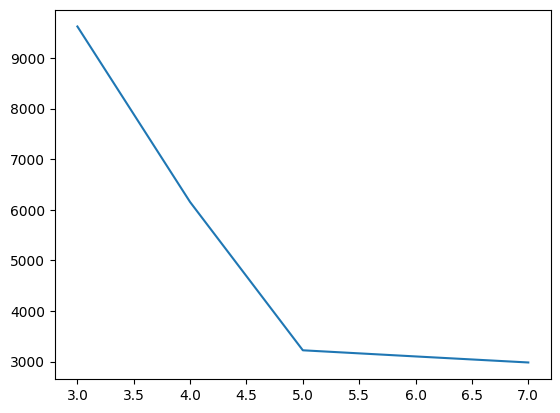

In [9]:
data = np.loadtxt(DATA_PATH / 'clusters.txt')
plot_elbow_graph(data, min_clusters=3, max_clusters=7)

In [10]:
pca = PCA(0.95)
pca.fit(data)

pca.n_components_

np.int64(6)

In [11]:
x_pca = pca.transform(data)
km = KMeans(n_clusters=5)
km.fit(x_pca)
km.inertia_

2192.118384651097

# Q24

In [12]:
x = np.loadtxt(DATA_PATH / 'lr_x.txt').reshape(-1,1)
y = np.loadtxt(DATA_PATH / 'lr_y.txt')

lr = LinearRegression()
lr.fit(x, y)

print(f"a = {lr.coef_[0]:.2f}, b={lr.intercept_:.2f}")

a = 0.55, b=19.86


# Q27

In [13]:
x = np.array([3,0.5,2,0.33])
P = np.array([
    [5,1,0,0],
    [1,2,0,0],
    [0,0,5,1],
    [0,0,1,2],
])
dt = 1

F = np.array([
    [1,1/dt,0,0],
    [0,1,0,0],
    [0,0,1,1/dt],
    [0,0,0,1]
])

x_next = F @ x
P_next = F @ P @ F.T

x_next, P_next

(array([3.5 , 0.5 , 2.33, 0.33]),
 array([[9., 3., 0., 0.],
        [3., 2., 0., 0.],
        [0., 0., 9., 3.],
        [0., 0., 3., 2.]]))

# Q28

In [14]:
x = np.array([5, 0.5, 7, 0.8])
P = np.array([
    [0.2, 0, 0, 0],
    [0.2, 0.1, 0, 0],
    [0, 0, 0.2, 0],
    [0, 0, 0.2, 0.1],
])

z = np.array([4.8, 7.1])
R = np.ones((2,2))*0.2

H = np.array([
    [1,0,0,0],
    [0,0,1,0]
])

y = z - H @ x
S = H @ P @ H.T + R
K = P @ H.T @ np.linalg.pinv(S)
x_next = x + K @ y

x_next

array([4.83333333, 0.33333333, 7.13333333, 0.93333333])